In [28]:
!pip install kneed
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import seaborn as sns
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.decomposition import PCA
import scipy.stats as ss
from sklearn.preprocessing import label_binarize
import re
import warnings
warnings.filterwarnings('ignore')

*The dataset exists to model and predict loan repayment behavior, helping lenders make informed decisions and manage risk.*

In [29]:
loan=pd.read_csv("https://raw.githubusercontent.com/aurorabintaymostafa/BRACU_CSE422_project/main/Loan_Assignment.xlsx%20-%20Sheet.csv")
print(f"The dataset has {loan.shape[0]} rows and {loan.shape[1]} columns.")

The dataset has 2247 rows and 16 columns.


In [30]:
print(loan)

            id  loan_amnt        term  int_rate  installment emp_length  \
0     68407277       3600   36 months     13.99       123.03  10+ years   
1     68355089      24700   36 months     11.99       820.28  10+ years   
2     68341763      20000   60 months     10.78       432.66  10+ years   
3     66310712      35000   60 months     14.85       829.90  10+ years   
4     68476807      10400   60 months     22.45       289.91    3 years   
...        ...        ...         ...       ...          ...        ...   
2242  68465005      15000   36 months      6.49       459.67    3 years   
2243  68535442      18000   36 months     12.88       605.46    8 years   
2244  66540973       4400   36 months      7.49       136.85    4 years   
2245  68495264      24000   36 months     10.78       783.24  10+ years   
2246  68485149       7000   36 months     11.99       232.47    5 years   

     home_ownership  annual_inc verification_status             purpose  \
0          MORTGAGE     

# EXPLORATORY DATA ANALYSIS

Identifying Data Quality Issues:

It helps detect:

 1. Missing values

2. Outliers

3. Duplicates

4. Inconsistent data types

Guiding Feature Engineering: EDA can show which features might be useful, which ones are redundant

Detecting Trends and Patterns: EDA reveals trends, seasonality, or clusters that can influence modeling decisions

Avoiding Wrong Assumptions:Looking at the raw data can prevent mistakes like assuming normal distribution when the data is skewed.

Improving Model Performance:

Better understanding of your data often leads to better preprocessing, which leads to more accurate models.

In [31]:
print(f"The dataset has {loan.shape[0]} rows and {loan.shape[1]} columns.")

The dataset has 2247 rows and 16 columns.


In [32]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2247 entries, 0 to 2246
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2247 non-null   int64  
 1   loan_amnt            2247 non-null   int64  
 2   term                 2247 non-null   object 
 3   int_rate             2247 non-null   float64
 4   installment          2247 non-null   float64
 5   emp_length           2146 non-null   object 
 6   home_ownership       2247 non-null   object 
 7   annual_inc           2247 non-null   float64
 8   verification_status  2247 non-null   object 
 9   purpose              2247 non-null   object 
 10  title                2193 non-null   object 
 11  zip_code             2247 non-null   object 
 12  dti                  2247 non-null   float64
 13  fico_range_low       2243 non-null   float64
 14  tot_cur_bal          2247 non-null   int64  
 15  loan_status          2247 non-null   o

NUMERICAL FEATURES

In [33]:
numerical_data = loan.select_dtypes(include='number')
numerical_features=numerical_data.columns.tolist()
print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 8 numerical features: 

['id', 'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_low', 'tot_cur_bal']


In [34]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2247.0,6.829454e+07,2.064876e+06,361774.00,68376689.00,68466144.00,6.854461e+07,68617057.00
loan_amnt,2247.0,1.526334e+04,8.673170e+03,1000.00,8400.00,14400.00,2.000000e+04,35000.00
int_rate,2247.0,1.224109e+01,4.414567e+00,5.32,8.49,11.99,1.485000e+01,28.49
installment,2247.0,4.451926e+02,2.493518e+02,31.11,261.08,393.83,5.977800e+02,1282.79
annual_inc,2247.0,7.969823e+04,4.505393e+04,11520.00,50000.00,70000.00,1.000000e+05,650000.00
dti,2247.0,1.936123e+01,8.524562e+00,0.00,13.13,18.82,2.550500e+01,46.71
fico_range_low,2243.0,6.972024e+02,3.191879e+01,660.00,670.00,690.00,7.150000e+02,845.00
tot_cur_bal,2247.0,1.611735e+05,1.614439e+05,356.00,37691.50,110760.00,2.435500e+05,1662218.00


In [35]:
numerical_data.var()

,0
id,4.263713e+12
loan_amnt,7.522388e+07
int_rate,1.948840e+01
installment,6.217633e+04
annual_inc,2.029857e+09
dti,7.266815e+01
fico_range_low,1.018809e+03
tot_cur_bal,2.606412e+10


CATEGORICAL FEATURES

In [36]:
categorical_data=loan.select_dtypes(include= 'object')
categorical_features=categorical_data.columns.tolist()
print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 8 categorical features: 

['term', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'title', 'zip_code', 'loan_status']


In [37]:
categorical_data.describe().T

,count,unique,top,freq
term,2247,2,36 months,1572
emp_length,2146,11,10+ years,793
home_ownership,2247,3,MORTGAGE,1227
verification_status,2247,3,Not Verified,875
purpose,2247,11,debt_consolidation,1324
title,2193,11,Debt consolidation,1299
zip_code,2247,587,300xx,29
loan_status,2247,5,Fully Paid,1652


Loan Status Distribution:
loan_status
Fully Paid            1652
Charged Off            581
Late (31-120 days)      11
In Grace Period          2
Late (16-30 days)        1
Name: count, dtype: int64

Unique Values in loan_status: 5


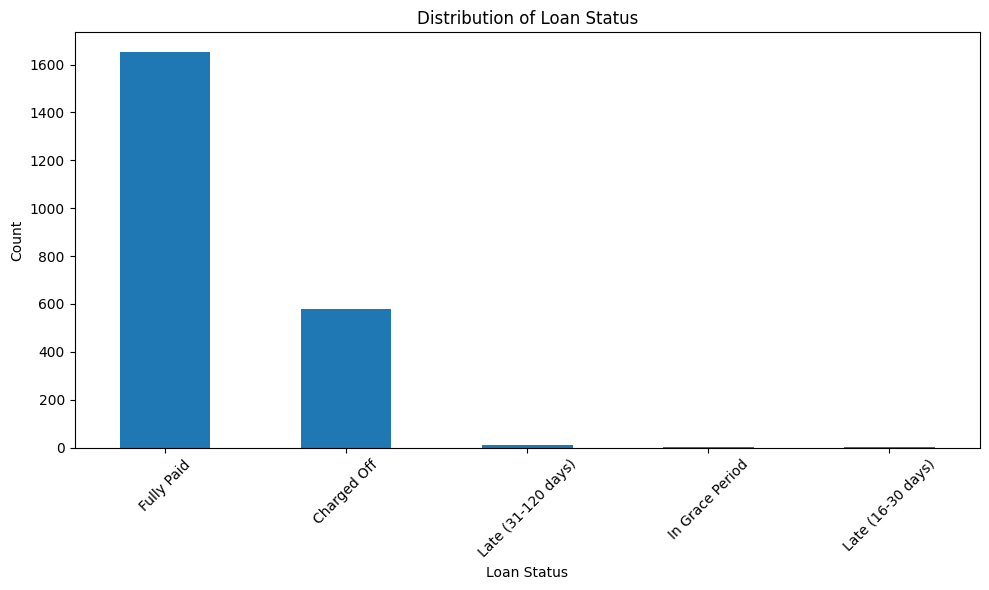

In [38]:
#checking for equal number or inctances
#Target variable analysis
print("Loan Status Distribution:")
print(loan['loan_status'].value_counts())
print("\nUnique Values in loan_status:", loan['loan_status'].nunique())

# Visualize target distribution
plt.figure(figsize=(10, 6))
loan['loan_status'].value_counts().plot(kind='bar')
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Skew in numerical features

📐 What is Skewness? Skewness measures the asymmetry of the distribution of a dataset.

Skewness = 0 → Perfectly symmetrical (e.g., normal distribution)

Skewness < 0 → Left-skewed (long tail on the left)

Skewness > 0 → Right-skewed (long tail on the right)

It helps you understand how balanced your data is and whether transformations are needed.

📊 Interpretation of Skewness Values:

Skewness Value Interpretation

~ 0 Symmetrical (normal-ish)

0 to ±0.5 Fairly symmetrical

±0.5 to ±1 Moderately skewed

greater than ±1 Highly skewed

In [39]:
numerical_data.skew()

,0
id,-31.525787
loan_amnt,0.570803
int_rate,0.610053
installment,0.822972
annual_inc,2.881768
dti,0.177989
fico_range_low,1.178515
tot_cur_bal,1.983520


INTERPRETATION OF SKEWNESS:

ID(-31.525787)- Left-skewed:Extremely negative skew. This is because id is just a unique identifier

loan_amnt(0.57)- Right skewed: Slight positive skew. Most loans are near the lower end

int_rate(0.61)- Right skewed: Slight positive skew. Interest rates slightly concentrated at lower values with some high outliers

installment(0.82)- Right skewed: Moderate positive skew. Monthly payments mostly small but some high values.

annual_inc(2.88)- Right skewed: Highly positively skewed. Most borrowers have low to mid incomes, but a few very high-income outliers.

dti(0.18)- Right skewed: Nearly symmetric . Debt-to-income ratio is fairly balanced.

fico_range_low(1.18)- Right skewed: Moderate positive skew. Most borrowers have FICO scores on the lower side of the range.

tot_cur_bal(1.98)- Right skewed: High positive skew. Most borrowers have moderate total current balances, but a few have very high balances.

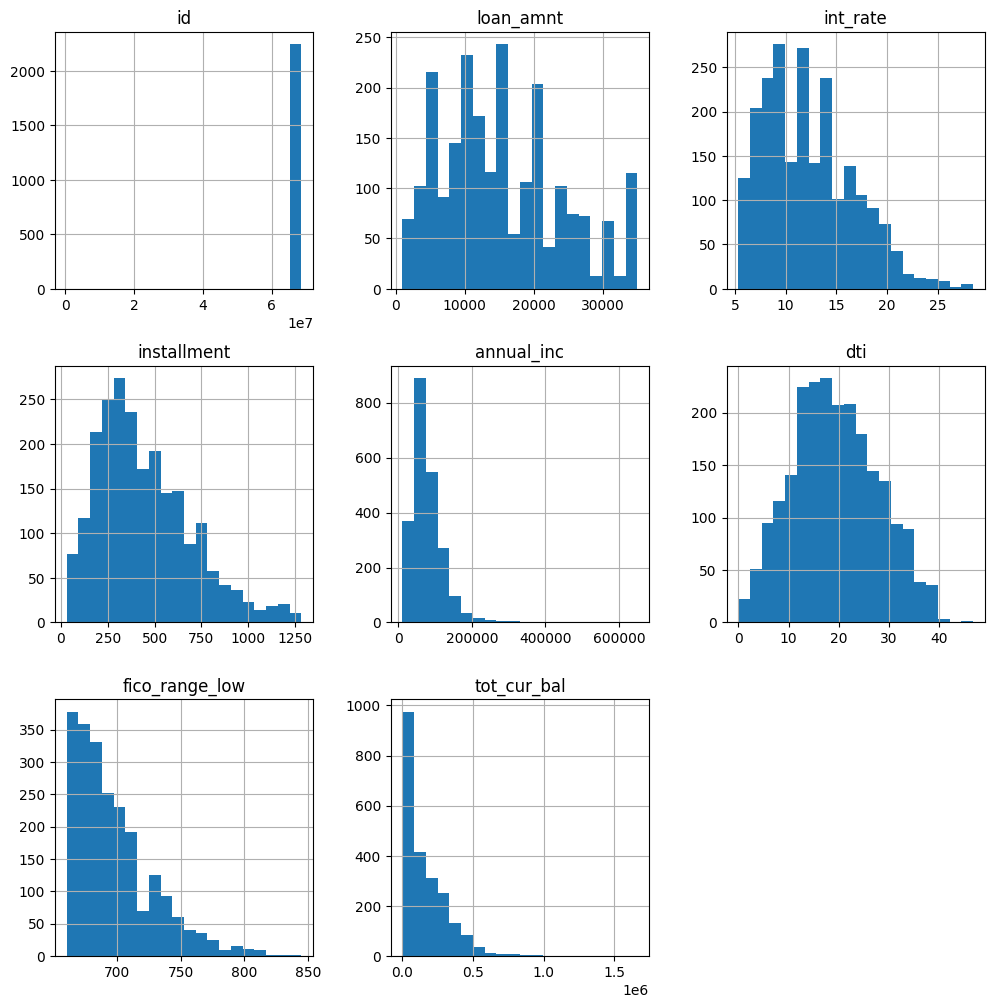

In [40]:
#USING HISTOGRAMS AND BOX PLOT: TO FIND DISTRIBUTIONS AND OUTLIERS OF EACH FEATURE
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

EXPLAINATION FROM THE PLOTS:

ID: Irrelevant-should be excluded from analysis

loan_amnt: Most loans cluster in the lower–mid range (≈ 5k–20k). A few very large loan amounts (above ~30k). Large loans are rare = high-end outliers

int_rate: Most interest rates lie between 7%–15%. Very high rates (> 25%) are outliers. High-risk borrowers are few but present.

installment: Most values are small to moderate. Very high installments (> ~1000) are outliers. Large monthly payments are uncommon and extreme.

annual_inc:Majority earn under 150k. Extremely high incomes (300k–600k+) are outliers.Classic income distribution=few ultra-high earners.

dti: Centered around 10–25.High DTI values (> 40) are outliers. Most borrowers are financially balanced; extreme debt cases exist.

tot_cur_bal:Most balances are small. Very large total balances (near 1.5e7) are outliers. A few individuals hold massive balances.

fico_range_low:Most values between 650–750. Very low FICO scores (< 600) and very high ones (> 820) are outliers. Majority are average-to-good credit borrowers.

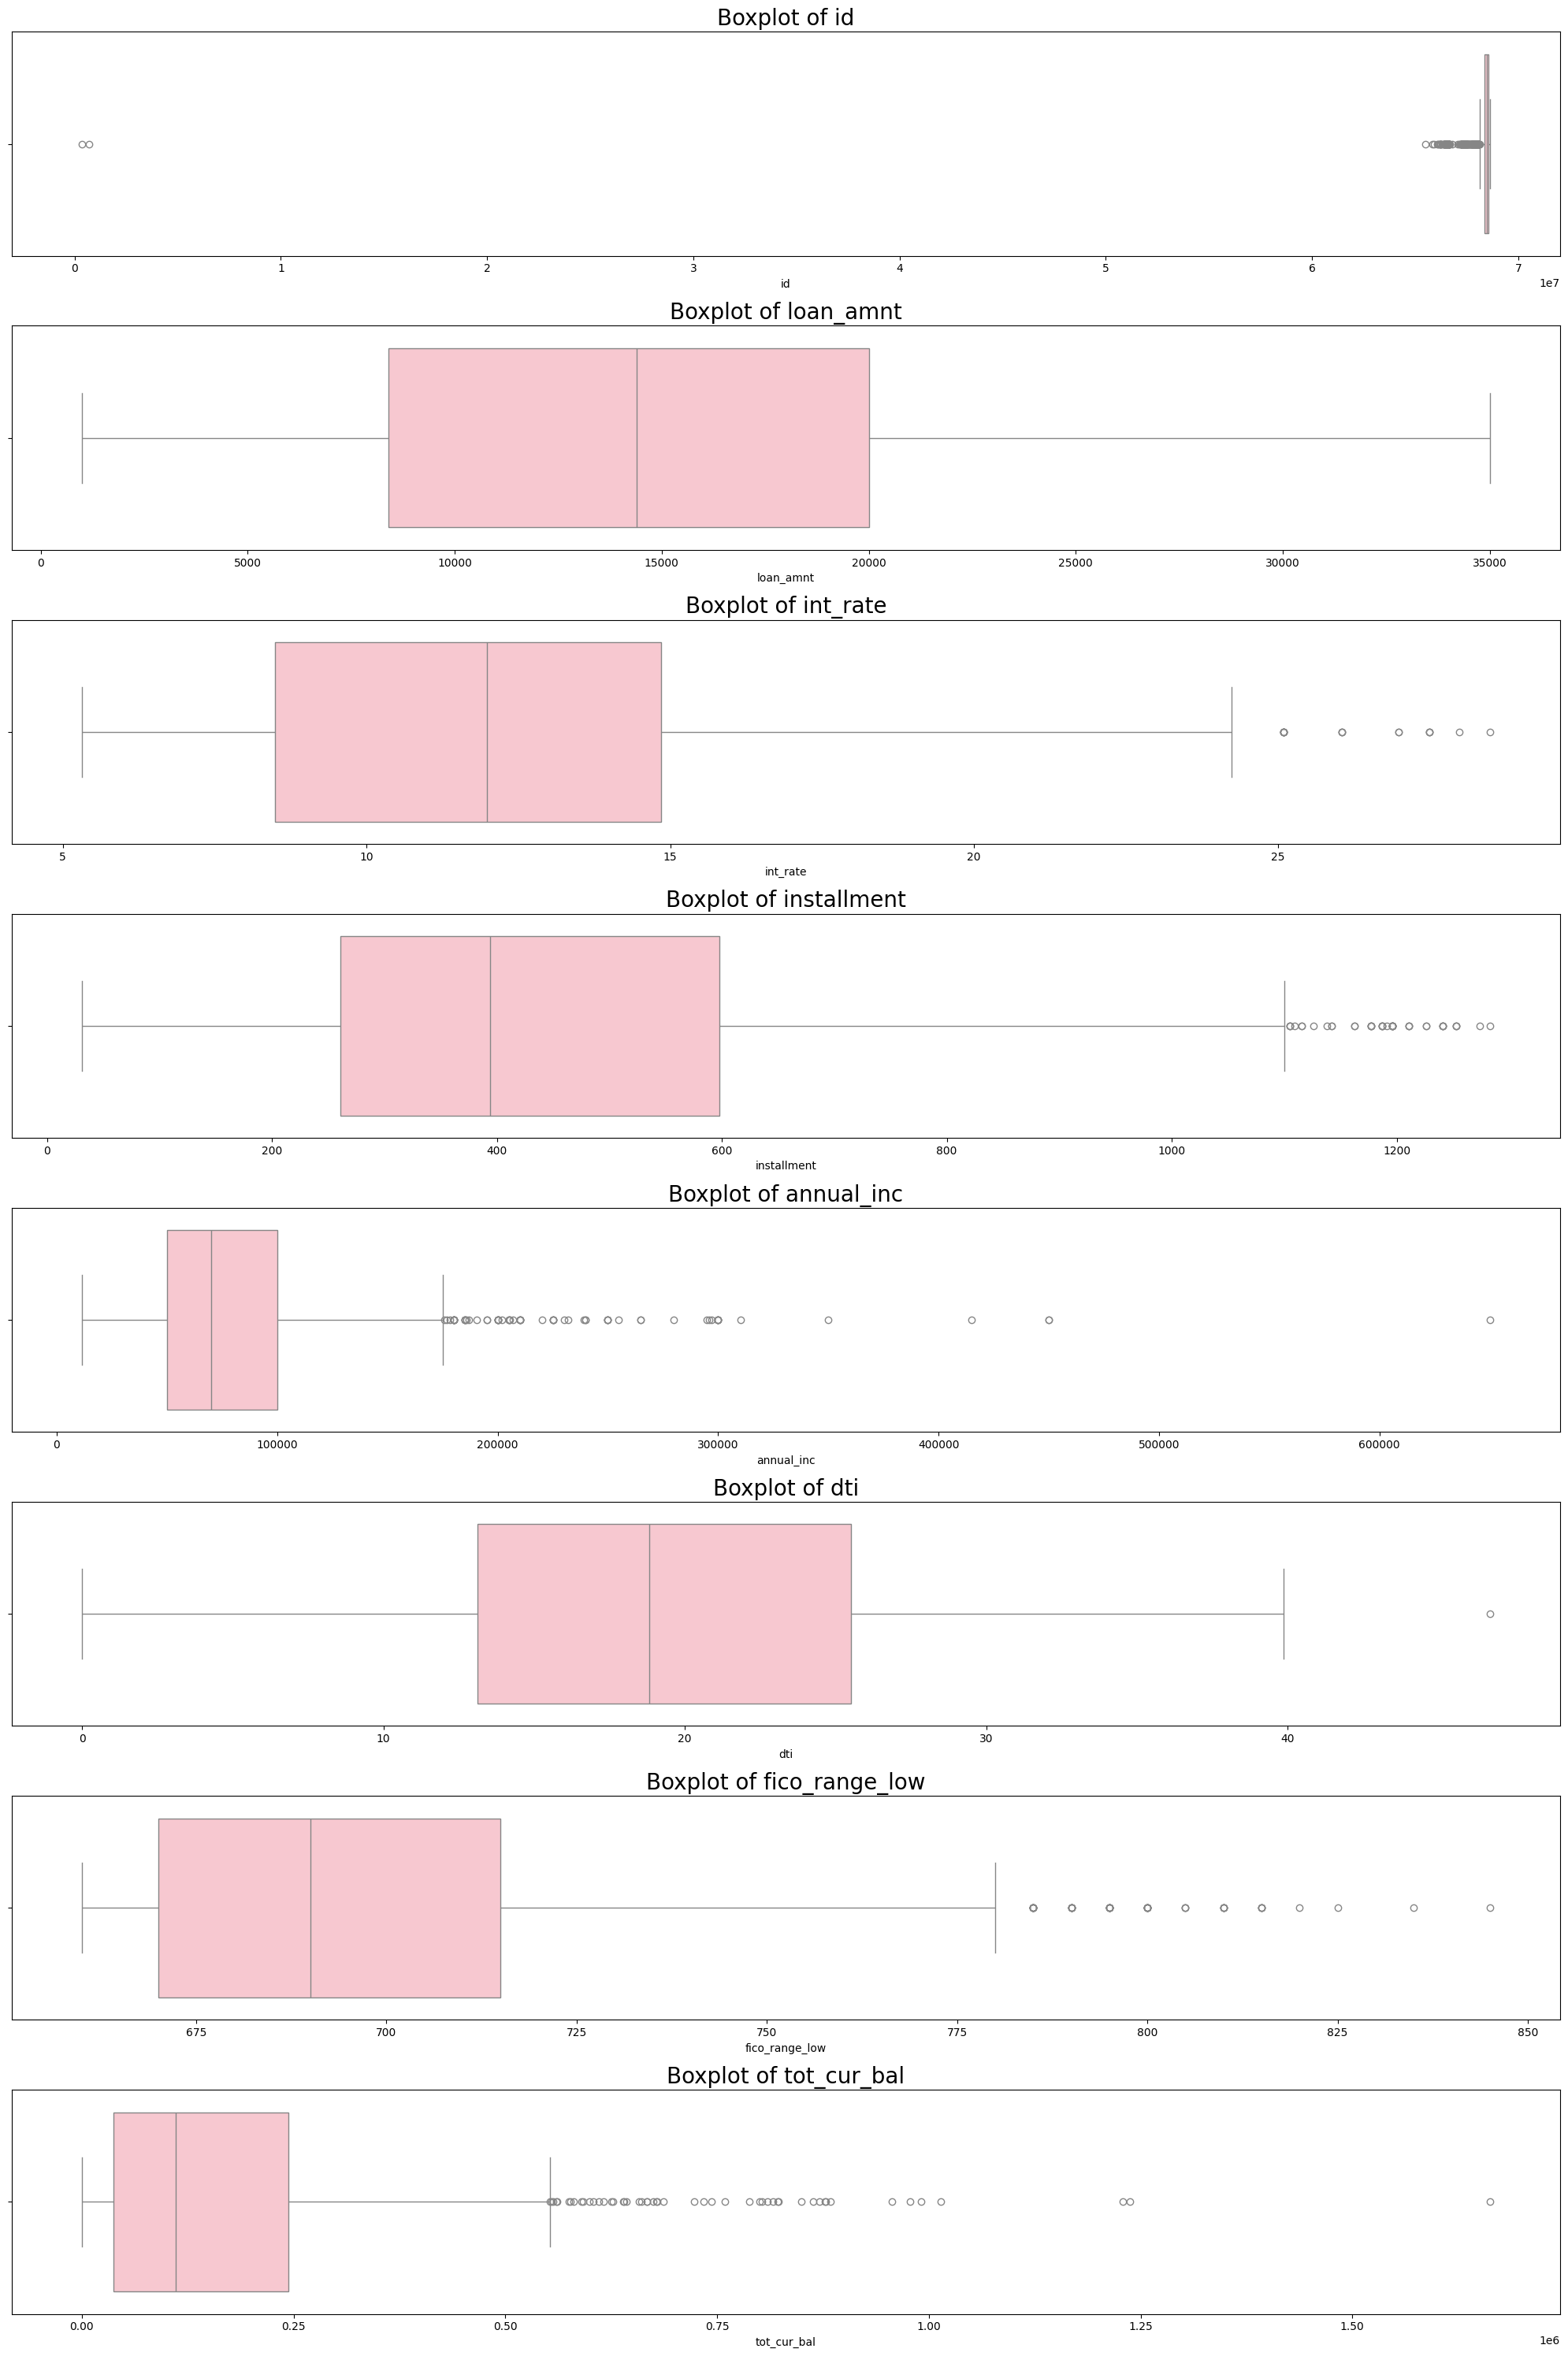

In [41]:
#Plot boxplots for each numerical feature including the target variable 'Loan Status'
numeric_cols = loan.select_dtypes(include=['int64', 'float64']).columns #Selects only numerical columns from the loan DataFrame.
plt.figure(figsize=(20, 30)) #Creates a large plotting area.
for i, col in enumerate(numeric_cols, 1): #Loops through each numerical column.
    plt.subplot(len(numeric_cols), 1, i) #Creates a subplot grid
    sns.boxplot(x=loan[col], color='pink') #Draws a boxplot using Seaborn
    plt.title(f'Boxplot of {col}', fontsize=20) #Adds a title for each boxplot.
    plt.tight_layout() #Automatically adjusts spacing between subplots.
plt.show() #Displays all generated boxplots.

Boxplot Interpretation (EDA Summary)

id: The id variable is an identifier and does not carry analytical meaning. Although extreme values appear as outliers, they are not meaningful and this variable should be removed from modeling.

loan_amnt: Loan amounts are concentrated in the lower to mid range, with a right-skewed distribution. A few large loan values appear as outliers, indicating rare but high-value loans.

int_rate: Most interest rates fall within a moderate range. Higher interest rates appear as outliers, representing a small group of high-risk borrowers.

installment: Monthly installment amounts are mostly moderate but show strong right skewness. Higher installment values appear as outliers, indicating larger repayment obligations.

annual_inc: Annual income is heavily right-skewed. Most borrowers earn moderate incomes, while a few extremely high-income values appear as outliers.

dti: Debt-to-income ratios are mostly within a reasonable range. Slight right skewness is observed, with very high DTI values appearing as outliers.

fico_range_low: Credit scores are concentrated in the average to good range. Very high credit scores appear as outliers, indicating borrowers with excellent credit histories.

tot_cur_bal: Total current balance is highly right-skewed. Most borrowers have low to moderate balances, while a few extremely large balances appear as strong outliers.

In [42]:
#Number Unique values in each feature
numerical_data.nunique()

,0
id,2247
loan_amnt,406
int_rate,35
installment,1248
annual_inc,500
dti,1567
fico_range_low,36
tot_cur_bal,2237


In [43]:
#unique values in each categorical feature
unique_counts=categorical_data.nunique()
print(unique_counts)

term                     2
emp_length              11
home_ownership           3
verification_status      3
purpose                 11
title                   11
zip_code               587
loan_status              5
dtype: int64


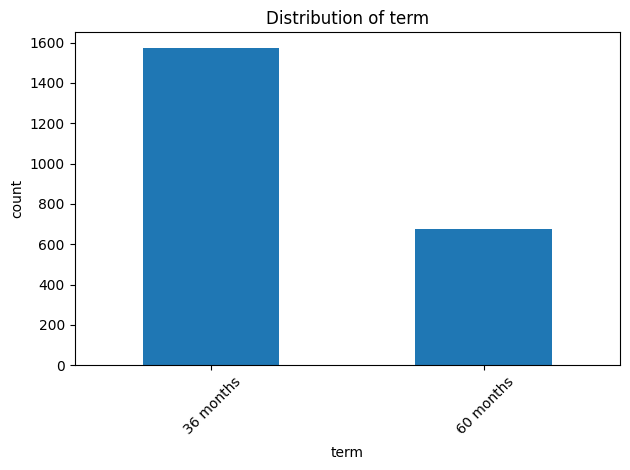

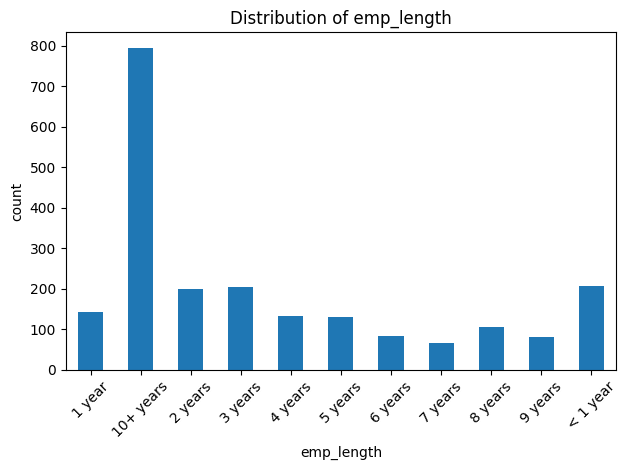

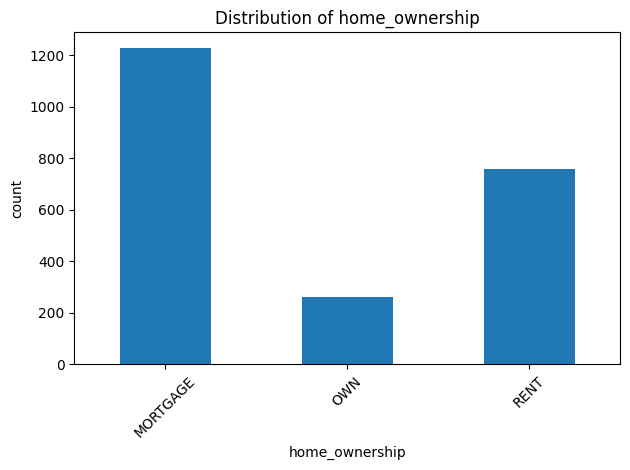

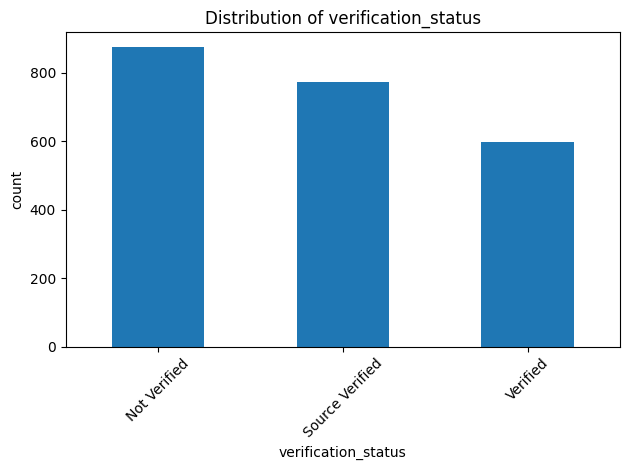

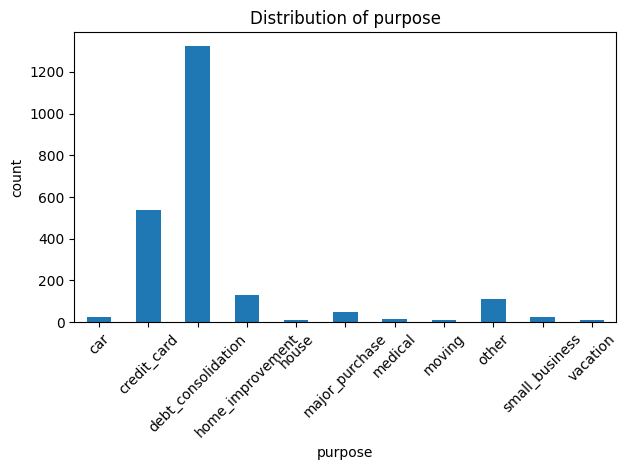

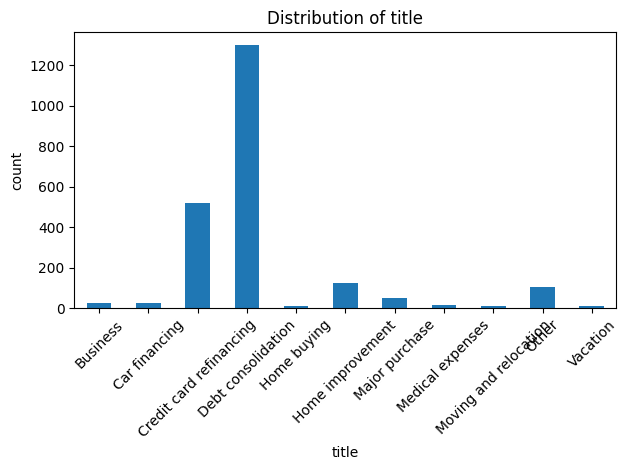

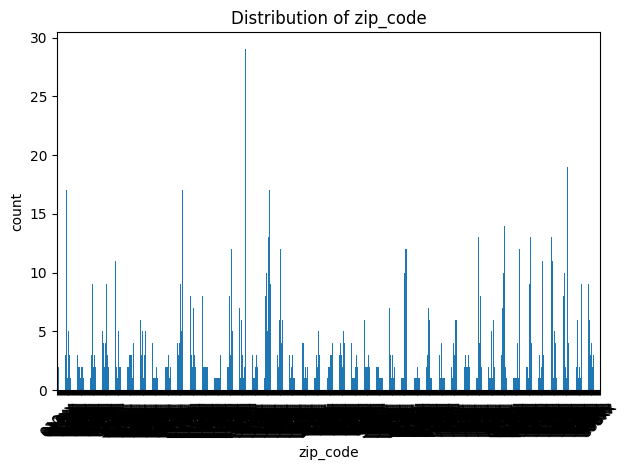

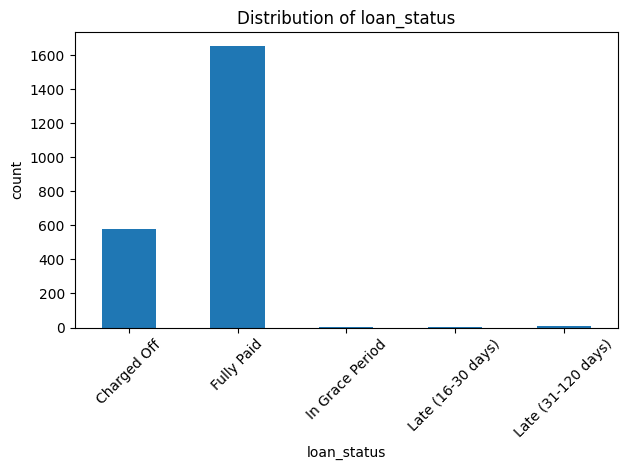

In [44]:
#Barplot of unique value counts in every categorical features
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=45, xlabel=col,ylabel='count')
    plt.tight_layout()
    plt.show()

In [45]:
# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()
correlation_matrix

,id,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,tot_cur_bal
id,1.000000,0.004208,0.008534,0.000601,-0.002153,0.040985,-0.018461,-0.011354
loan_amnt,0.004208,1.000000,0.170932,0.944283,0.429152,0.034784,0.079489,0.294110
int_rate,0.008534,0.170932,1.000000,0.151512,-0.098429,0.225212,-0.403774,-0.069708
installment,0.000601,0.944283,0.151512,1.000000,0.406324,0.028254,0.036283,0.247747
annual_inc,-0.002153,0.429152,-0.098429,0.406324,1.000000,-0.201245,0.068489,0.541419
dti,0.040985,0.034784,0.225212,0.028254,-0.201245,1.000000,-0.083926,0.006317
fico_range_low,-0.018461,0.079489,-0.403774,0.036283,0.068489,-0.083926,1.000000,0.144776
tot_cur_bal,-0.011354,0.294110,-0.069708,0.247747,0.541419,0.006317,0.144776,1.000000


Correlation Matrix Interpretation

id: The id variable shows near-zero correlation with all features, confirming it has no analytical significance and should be excluded from modeling.

loan_amnt & installment (0.94): There is a very strong positive correlation, indicating that higher loan amounts result in higher monthly installments. This suggests potential multicollinearity.

loan_amnt & annual_inc (0.43): A moderate positive correlation shows that borrowers with higher income tend to take larger loans.

annual_inc & tot_cur_bal (0.54): A moderate to strong positive correlation indicates that higher-income borrowers generally maintain higher total balances.

int_rate & fico_range_low (-0.40): A moderate negative correlation shows that borrowers with higher credit scores receive lower interest rates, which aligns with lending practices.

int_rate & dti (0.23): A weak to moderate positive correlation, suggesting higher debt-to-income ratios are associated with higher interest rates.

annual_inc & dti (-0.20): A weak negative correlation, meaning higher income borrowers generally have lower debt burdens.

tot_cur_bal & loan_amnt (0.29): A weak to moderate positive correlation, indicating borrowers with higher balances tend to take slightly larger loans.

fico_range_low: Shows weak correlations with most variables except interest rate, suggesting it captures credit quality independently.

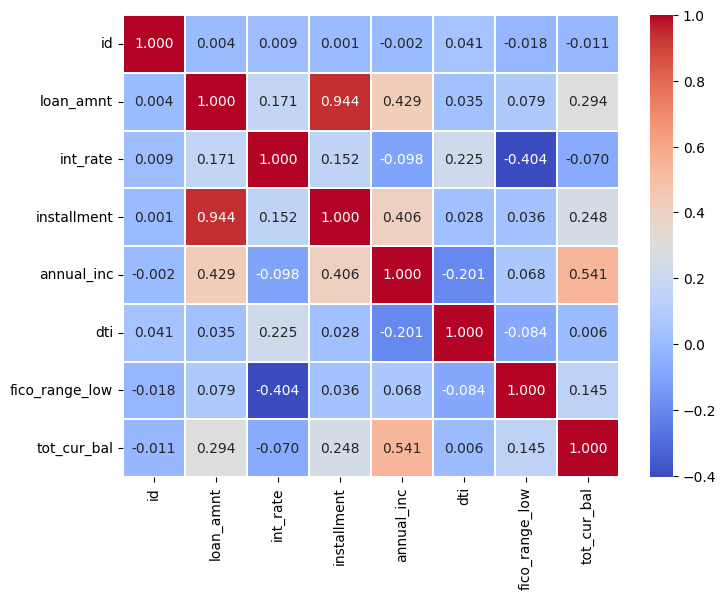

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

Generating correlation plot between features and target variable using different method Some Correlation techniques 🔹 1. Pearson Correlation Coefficient

📌 Purpose: Measures the linear relationship between two continuous (numeric) variables.

💡 Characteristics:

Value ranges from -1 to +1

+1: Perfect positive linear correlation

-1: Perfect negative linear correlation

0: No linear relationship

Sensitive to outliers.

✅ Used For: Finding how variables like CREDIT_SCORE, ANNUAL_MILEAGE, DUIS, etc., relate to each other or the OUTCOME.

🔹 2. Cramér's V (for Categorical-Categorical Correlation)

📌 Purpose: Measures the association between two categorical variables.

💡 Characteristics:

Value ranges from 0 to 1

0: No association

1: Perfect association

Based on Chi-Square statistics

✅ Used For: Checking relationships between columns like GENDER, EDUCATION, INCOME, TYPE_OF_VEHICLE, etc.

🔹 3. Point-Biserial Correlation (for Continuous vs Binary)

📌 Purpose: A special case of Pearson correlation used when one variable is binary (e.g., 0 or 1) and the other is continuous.

💡 Characteristics:

Essentially checks if the means of the two binary groups are different in a statistically linear sense.

✅ Used For: Relating binary target OUTCOME with features like:

CREDIT_SCORE

ANNUAL_MILEAGE

PAST_ACCIDENTS

etc.

🔹 4. Spearman Rank Correlation

📌 Purpose: Measures monotonic relationships between two variables — whether linear or non-linear.

💡 Characteristics:

Uses rank values rather than raw data.

Value range: -1 to +1

Less sensitive to outliers than Pearson

Ideal for ordinal data or when relationships are not linear.

✅ Use Case: DRIVING_EXPERIENCE (ordinal) vs OUTCOME

AGE group vs CREDIT_SCORE

🔹 5. Kendall’s Tau

📌 Purpose: Also measures ordinal association between two variables using pairwise concordance.

💡 Characteristics:

More conservative than Spearman

Interprets strength of monotonic relationships

Value range: -1 to +1

Better for smaller datasets or when many ties exist in the ranks

✅ Use Case: Similar to Spearman — works well with ranks and ties.

Index(['id', 'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
       'fico_range_low', 'tot_cur_bal', 'loan_status'],
      dtype='object')


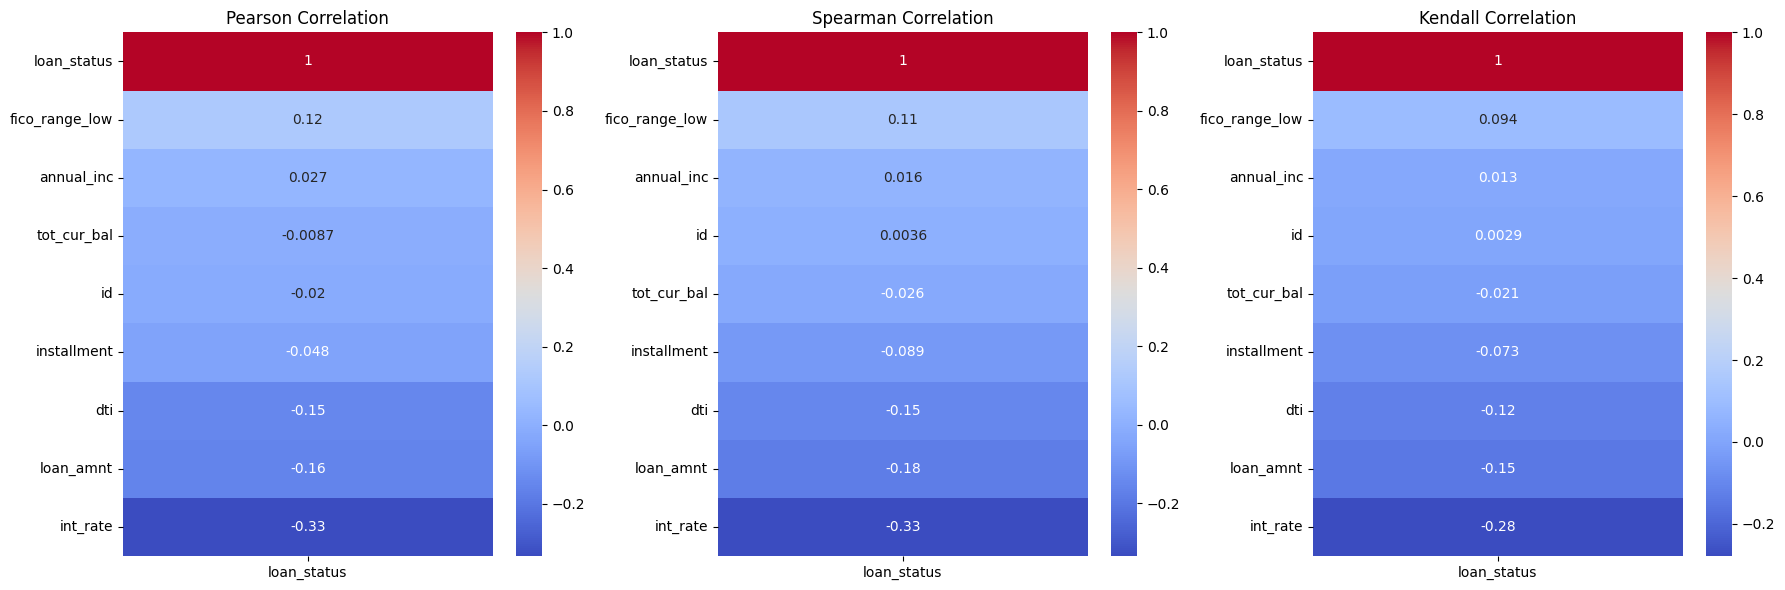

In [47]:
#Correlation plot between numerical features and target
loan['loan_status'] = loan['loan_status'].map({"Fully Paid": 3,'In Grace Period':2,'Late (16-30 days)':1,'Late (31-120 days)':1,'Charged Off': 0})


numerical_data = loan.select_dtypes(include='number')

print(numerical_data.columns)

corr_pearson = numerical_data.corr(method='pearson')[['loan_status']] \
                             .sort_values(by='loan_status', ascending=False)

corr_spearman = numerical_data.corr(method='spearman')[['loan_status']] \
                               .sort_values(by='loan_status', ascending=False)

corr_kendall = numerical_data.corr(method='kendall')[['loan_status']] \
                              .sort_values(by='loan_status', ascending=False)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].set_title('Pearson Correlation')
ax[1].set_title('Spearman Correlation')
ax[2].set_title('Kendall Correlation')

sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', ax=ax[0])
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', ax=ax[1])
sns.heatmap(corr_kendall, annot=True, cmap='coolwarm', ax=ax[2])

plt.tight_layout()
plt.show()

**Correlation & Distribution Summary (Loan Dataset)**

| Feature            | Pearson Corr. (≈) | Spearman Corr. (≈) | Kendall Corr. (≈) | Relationship with Loan Status | Evidence from Plots                                                 |
| ------------------ | ----------------- | ------------------ | ----------------- | ----------------------------- | ------------------------------------------------------------------- |
| **int_rate**       | −0.33             | −0.33              | −0.28             | Strong negative               | High interest rates dominate default cases; many high-rate outliers |
| **loan_amnt**      | −0.16             | −0.18              | −0.15             | Moderate negative             | Larger loan amounts show wider spread and higher risk               |
| **dti**            | −0.15             | −0.15              | −0.12             | Moderate negative             | Right-skewed distribution with high DTI outliers                    |
| **fico_range_low** | +0.12             | +0.11              | +0.10             | Weak positive                 | Higher FICO scores cluster among fully paid loans                   |
| **installment**    | −0.05             | −0.08              | −0.07             | Weak negative                 | High installment values appear as right-tail outliers               |
| **annual_inc**     | +0.03             | +0.02              | +0.02             | Very weak positive            | Highly right-skewed with many extreme income outliers               |
| **tot_cur_bal**    | ≈ 0.00            | −0.02              | −0.01             | No meaningful relationship    | Extreme skewness and large balance outliers                         |
| **id**             | ≈ 0.00            | ≈ 0.00             | ≈ 0.00            | None (irrelevant)             | Identifier only; no predictive value                                |
| **emp_length**     | —                 | —                  | —                 | Not correlated                | Categorical variable; histogram shows majority with 10+ years       |


In [48]:
#check Imbalance in data

# Group instances based on loan_status_num
class_counts = loan.groupby("loan_status").size()
total_samples = len(loan) # Total number of observations
columns = ['loan_status', 'count', 'percentage'] # Prepare lists
outcome = [0, 1,2,3]
count = []
percentage = []
for val in outcome:     # Calculate count and percentage
    count.append(class_counts.get(val, 0))
    percent = (class_counts.get(val, 0) / total_samples) * 100
    percentage.append(percent)
imbalance_df = pd.DataFrame(list(zip(outcome, count, percentage)),columns=columns) # Convert to DataFrame

imbalance_df

,loan_status,count,percentage
0,0,581,25.856698
1,1,12,0.534045
2,2,2,0.089008
3,3,1652,73.520249


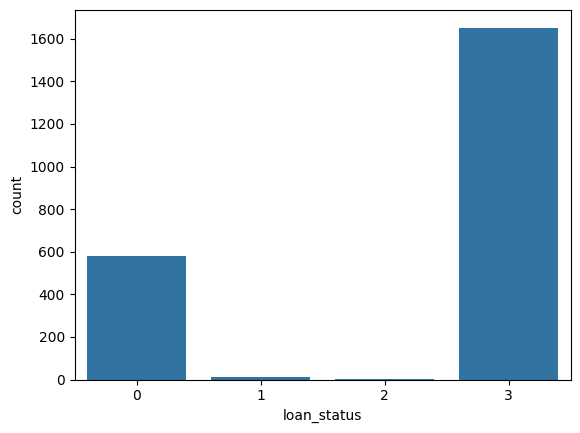

In [49]:
sns.barplot(data=imbalance_df,x='loan_status',y='count')
plt.show()

# OBSERVATION
Based on the values obtained above, 26% of the loan stauses are of value '0' and 74% are of value '1'. Thus , there exixts an imbalance of 48%.

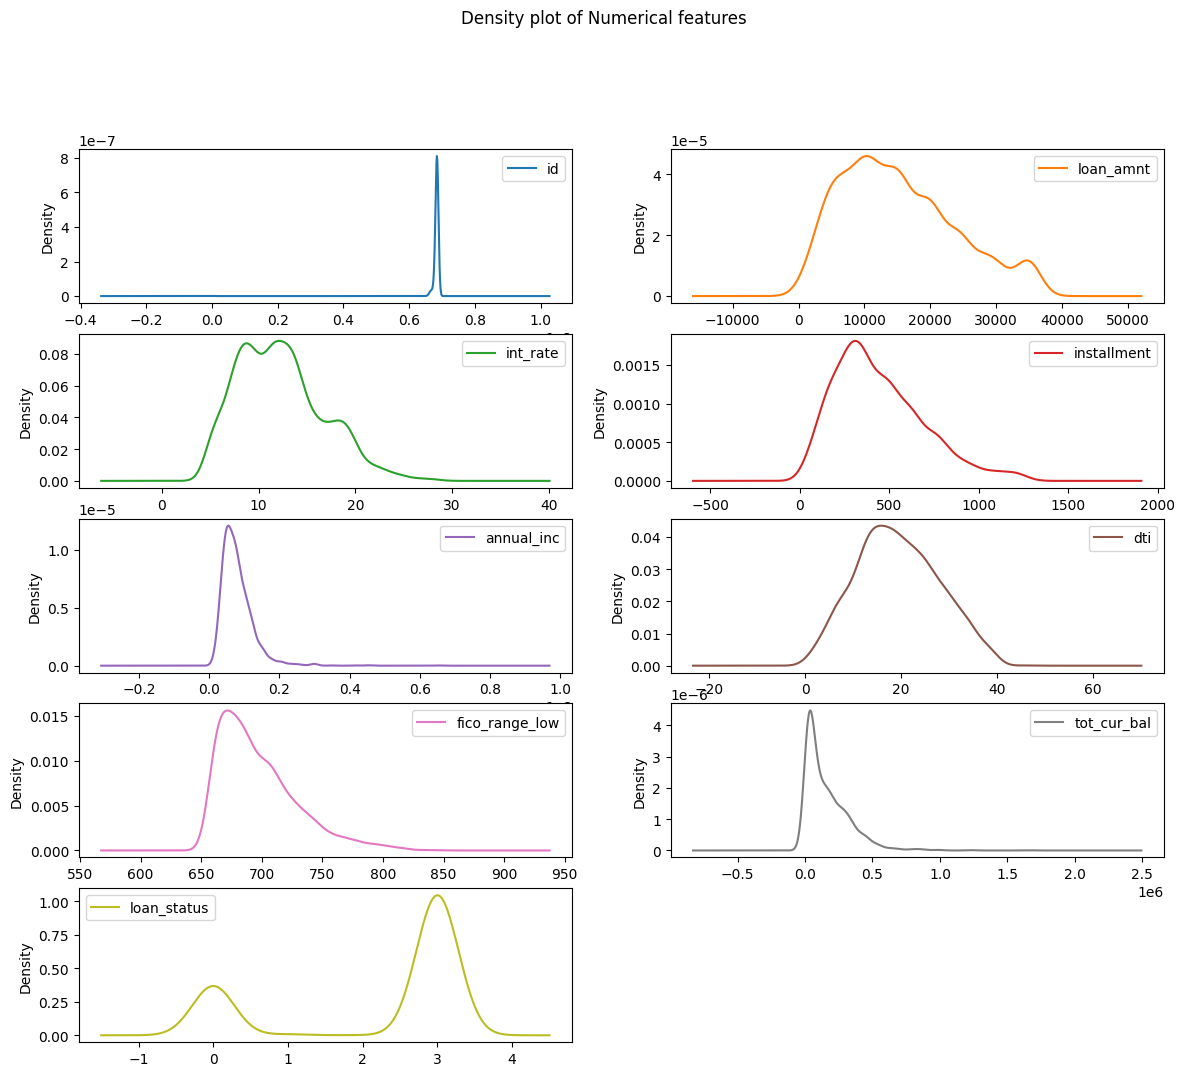

In [50]:
#DENSITY PLOTS
numerical_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

# DATA PREPROCESSING

In [51]:
#CHECKING FOR NULL VALUES
print(loan.isnull().sum())

id                       0
loan_amnt                0
term                     0
int_rate                 0
installment              0
emp_length             101
home_ownership           0
annual_inc               0
verification_status      0
purpose                  0
title                   54
zip_code                 0
dti                      0
fico_range_low           4
tot_cur_bal              0
loan_status              0
dtype: int64


In [52]:
#ELIMINATION OF FEATURES THAT ARE REDUNDANT
#TITLE, ID AND ZIP CODE OF THE BORROWER IS USELESS IN THIS DATASET
loan.drop(columns=['id', 'title', 'zip_code'], inplace=True)
print(f"The dataset has {loan.shape[0]} rows and {loan.shape[1]} columns.")

The dataset has 2247 rows and 13 columns.


In [53]:
#DROPPING ROWS WITH NULL VALUES
#loan.dropna(inplace=True)

In [54]:
print(loan.isnull().sum())

loan_amnt                0
term                     0
int_rate                 0
installment              0
emp_length             101
home_ownership           0
annual_inc               0
verification_status      0
purpose                  0
dti                      0
fico_range_low           4
tot_cur_bal              0
loan_status              0
dtype: int64


In [55]:
#Returns 0 for missing values (NaN) or very short employment ("< 1 year").
#Extracts the first number from the text (e.g., "10+ years" → 10, "3 years" → 3).
#Ensures the emp_length column becomes numeric, so it can be used in calculations, correlations, and machine learning models.

def emp_to_num(emp):
    if pd.isna(emp):
        return 0
    if '<' in emp :
             return 0
    nums = re.findall(r'\d+', emp)
    return int(nums[0]) if nums else 0

loan['emp_length'] = loan['emp_length'].apply(emp_to_num)

In [56]:
loan=loan.fillna(0)

In [57]:
print(loan.isnull().sum())
print(loan)

loan_amnt              0
term                   0
int_rate               0
installment            0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
dti                    0
fico_range_low         0
tot_cur_bal            0
loan_status            0
dtype: int64
      loan_amnt        term  int_rate  installment  emp_length home_ownership  \
0          3600   36 months     13.99       123.03          10       MORTGAGE   
1         24700   36 months     11.99       820.28          10       MORTGAGE   
2         20000   60 months     10.78       432.66          10       MORTGAGE   
3         35000   60 months     14.85       829.90          10       MORTGAGE   
4         10400   60 months     22.45       289.91           3       MORTGAGE   
...         ...         ...       ...          ...         ...            ...   
2242      15000   36 months      6.49       459.67           3       MORTGAGE   
2243      1800

In [58]:
# Numerical columns
target=loan['loan_status']
numerical_cols = loan.select_dtypes(include=['int64', 'float64']).drop('loan_status', axis=1, errors='ignore').columns

# Categorical columns
categorical_cols = loan.select_dtypes(include='object').columns

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: Index(['loan_amnt', 'int_rate', 'installment', 'emp_length', 'annual_inc',
       'dti', 'fico_range_low', 'tot_cur_bal'],
      dtype='object')
Categorical: Index(['term', 'home_ownership', 'verification_status', 'purpose'], dtype='object')


# FEATURE SCALING

In [59]:
# Preprocessing pipeline
preprocess = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

loan_processed = preprocess.fit_transform(loan)

print("Processed feature shape:", loan_processed.shape)

Processed feature shape: (2247, 27)


In [60]:
print(loan_processed)

[[-1.34506022  0.3962571  -1.29228783 ...  0.          0.
   0.        ]
 [ 1.08827111 -0.05688934  1.50458456 ...  0.          1.
   0.        ]
 [ 0.54624944 -0.33104294 -0.05027191 ...  0.          0.
   0.        ]
 ...
 [-1.25280121 -1.07646883 -1.23685179 ...  0.          0.
   0.        ]
 [ 1.00754448 -0.33104294  1.35600635 ...  0.          0.
   0.        ]
 [-0.95295944 -0.05688934 -0.85329219 ...  0.          0.
   0.        ]]


In [61]:
print(f"The dataset has {loan.shape[0]} rows and {loan.shape[1]} columns.")

The dataset has 2247 rows and 13 columns.


# TRAIN TEST_SPLIT

In [62]:
# For the full target before splitting
print(target.value_counts())


loan_status
3    1652
0     581
1      12
2       2
Name: count, dtype: int64


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    loan_processed, target,
stratify=target) #keeps class distribution balanced

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts())
print("\nTest class distribution:")
print(pd.Series(y_test).value_counts())

Train shape: (1685, 27)
Test shape: (562, 27)

Train class distribution:
loan_status
3    1239
0     436
1       9
2       1
Name: count, dtype: int64

Test class distribution:
loan_status
3    413
0    145
1      3
2      1
Name: count, dtype: int64


# MODEL BUILDING

In [64]:
#Counts how many unique classes there are
unique_labels = np.unique(np.concatenate([y_train, y_test]))
n_classes = len(unique_labels)
print(f"Number of classes: {n_classes}, Classes: {unique_labels}")


Number of classes: 4, Classes: [0 1 2 3]


In [65]:
#Count for each class
class_counts = loan['loan_status'].value_counts()
print(class_counts)

loan_status
3    1652
0     581
1      12
2       2
Name: count, dtype: int64


K=3 → CV Accuracy: 0.7285
K=5 → CV Accuracy: 0.7388
K=7 → CV Accuracy: 0.7468
K=9 → CV Accuracy: 0.7548
K=11 → CV Accuracy: 0.7534

Best K: 9 with CV Accuracy: 0.7547735708982926

Optimized KNN Accuracy: 0.7633

Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.59      0.33      0.42       145
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         1
           3       0.79      0.92      0.85       413

    accuracy                           0.76       562
   macro avg       0.34      0.31      0.32       562
weighted avg       0.73      0.76      0.74       562



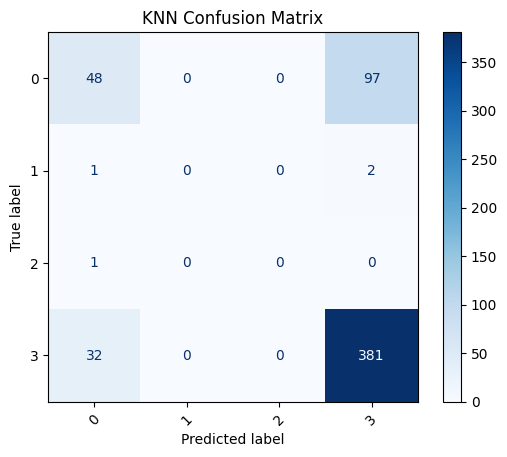

KNN Precision (weighted): 0.7343
KNN Recall (weighted): 0.7633


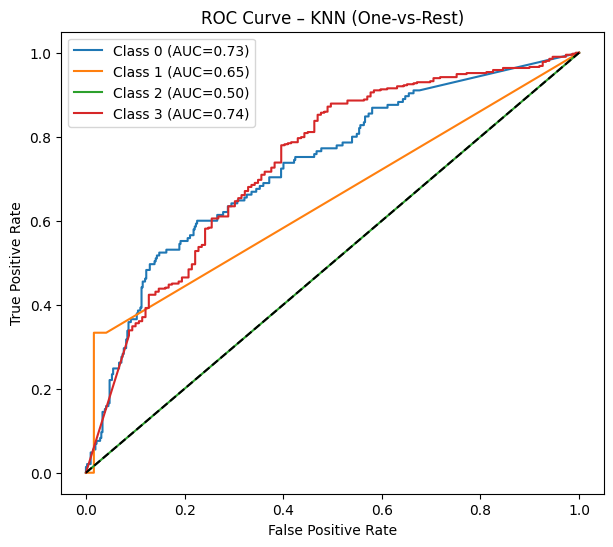

In [66]:
# Find optimal KNN using cross-validation
k_values = [3, 5, 7, 9, 11]
results_knn = {}

for k in k_values:
    knn_cv = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        metric='manhattan'
    )
    scores = cross_val_score(
        knn_cv,
        loan_processed,
        target,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    results_knn[k] = scores.mean()
    print(f"K={k} → CV Accuracy: {scores.mean():.4f}")

# Best K
best_k = max(results_knn, key=results_knn.get)
print("\nBest K:", best_k, "with CV Accuracy:", results_knn[best_k])

# Train FINAL optimized KNN which will be used for prediction

knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    metric='manhattan'
)

knn.fit(X_train, y_train)

# Predictions
y_pred_knn = knn.predict(X_test)
y_pred_proba_knn = knn.predict_proba(X_test)

# Evaluation
print(f"\nOptimized KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

print("\nClassification Report (KNN):")
print(classification_report(
    y_test,
    y_pred_knn,
    labels=unique_labels,
    target_names=[str(c) for c in unique_labels]
))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=unique_labels)
ConfusionMatrixDisplay(
    cm_knn,
    display_labels=[str(c) for c in unique_labels]
).plot(xticks_rotation=45, cmap='Blues')

plt.title("KNN Confusion Matrix")
plt.show()

#precision

from sklearn.metrics import precision_score, recall_score
precision_knn = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)

print(f"KNN Precision (weighted): {precision_knn:.4f}")
print(f"KNN Recall (weighted): {recall_knn:.4f}")
#roc curve
y_test_bin = label_binarize(y_test, classes=unique_labels)

plt.figure(figsize=(7,6))

for i, cls in enumerate(unique_labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba_knn[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_pred_proba_knn[:, i])

    plt.plot(fpr, tpr, label=f"Class {cls} (AUC={auc_score:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN (One-vs-Rest)")
plt.legend()
plt.show()


Logistic Regression Accuracy: 0.7705

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.60      0.41      0.49       145
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         1
           3       0.81      0.90      0.85       413

    accuracy                           0.77       562
   macro avg       0.35      0.33      0.34       562
weighted avg       0.75      0.77      0.75       562



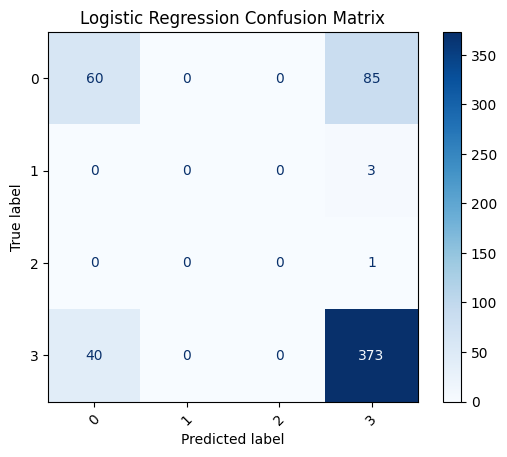

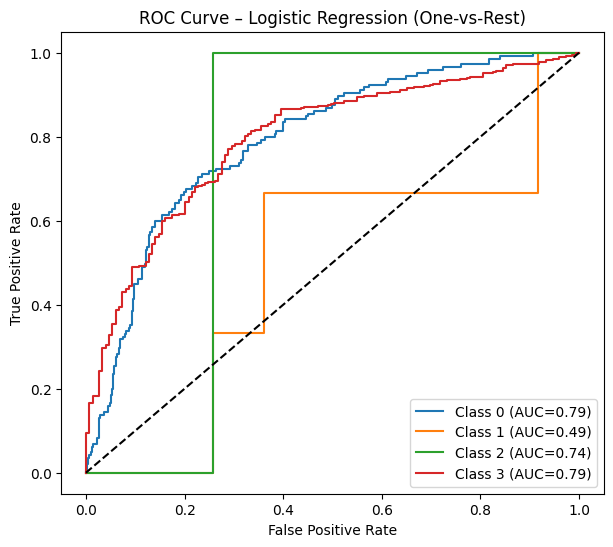

In [67]:
# LOGISTIC REGRESSION (Multiclass)
lr = LogisticRegression(
    max_iter=2000,
    multi_class='multinomial',
    solver='lbfgs'
)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Align predict_proba with all labels
y_pred_proba_lr_raw = lr.predict_proba(X_test)
y_pred_proba_lr = np.zeros((X_test.shape[0], n_classes))
for idx, cls in enumerate(lr.classes_):
    if cls in unique_labels:
        col = np.where(unique_labels == cls)[0][0]
        y_pred_proba_lr[:, col] = y_pred_proba_lr_raw[:, idx]

# Accuracy and classification report
print(f"\nLogistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr, labels=unique_labels, target_names=[str(c) for c in unique_labels]))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=unique_labels)
ConfusionMatrixDisplay(cm_lr, display_labels=[str(c) for c in unique_labels]).plot(
    xticks_rotation=45, cmap='Blues'
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


y_test_bin = label_binarize(y_test, classes=unique_labels)

plt.figure(figsize=(7,6))

for i, cls in enumerate(unique_labels):

    # Skip classes with no positive samples in test set
    if np.sum(y_test_bin[:, i]) == 0 or np.sum(y_test_bin[:, i]) == len(y_test_bin):
        continue

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba_lr[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_pred_proba_lr[:, i])

    plt.plot(fpr, tpr, label=f"Class {cls} (AUC={auc_score:.2f})")

# Diagonal reference line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression (One-vs-Rest)")
plt.legend()
plt.show()

Class weights: {0: np.float64(0.9661697247706422), 1: np.float64(46.80555555555556), 2: np.float64(421.25), 3: np.float64(0.3399919289749798)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,116 (164.52 KB)

 Trainable params: 41,348 (161.52 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
53/53 - 5s - 97ms/step - accuracy: 0.3840 - loss: 2.5724 - val_accuracy: 0.6673 - val_loss: 1.1101
Epoch 2/100
53/53 - 0s - 6ms/step - accuracy: 0.4178 - loss: 1.0396 - val_accuracy: 0.6121 - val_loss: 1.0873
Epoch 3/100
53/53 - 1s - 13ms/step - accuracy: 0.4730 - loss: 0.8769 - val_accuracy: 0.6228 - val_loss: 1.0495
Epoch 4/100
53/53 - 1s - 11ms/step - accuracy: 0.5009 - loss: 0.8611 - val_accuracy: 0.6441 - val_loss: 1.0036
Epoch 5/100
53/53 - 1s - 14ms/step - accuracy: 0.5300 - loss: 0.7283 - val_accuracy: 0.6886 - val_loss: 0.9399
Epoch 6/100
53/53 - 1s - 11ms/step - accuracy: 0.5377 - loss: 1.0350 - val_accuracy: 0.5854 - val_loss: 1.0424
Epoch 7/100
53/53 - 0s - 6ms/step - accuracy: 0.5383 - loss: 0.7392 - val_accuracy: 0.6512 - val_loss: 0.9506
Epoch 8/100
53/53 - 0s - 7ms/step - accuracy: 0.5757 - loss: 0.7132 - val_accuracy: 0.6904 - val_loss: 0.8956
Epoch 9/100
53/53 - 1s - 12ms/step - accuracy: 0.6142 - loss: 0.5753 - val_accuracy: 0.7046 - val_loss: 0.8522
Epoc

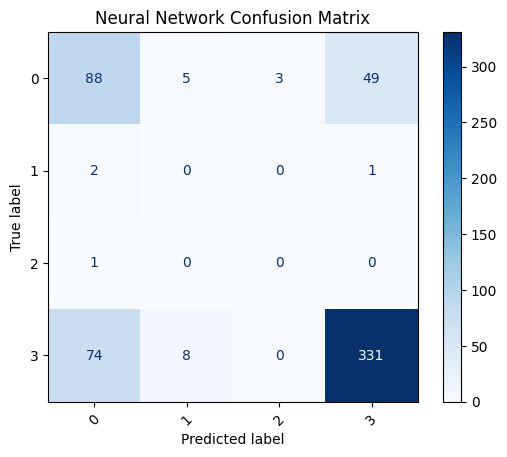

Neural Network Precision (weighted): 0.7760
Neural Network Recall (weighted): 0.7456


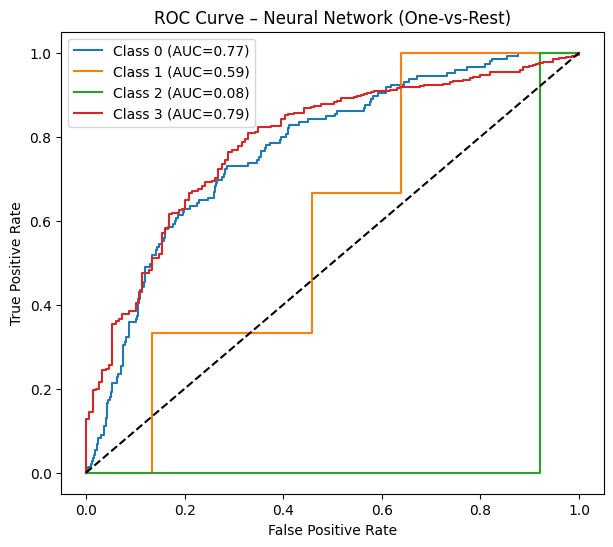

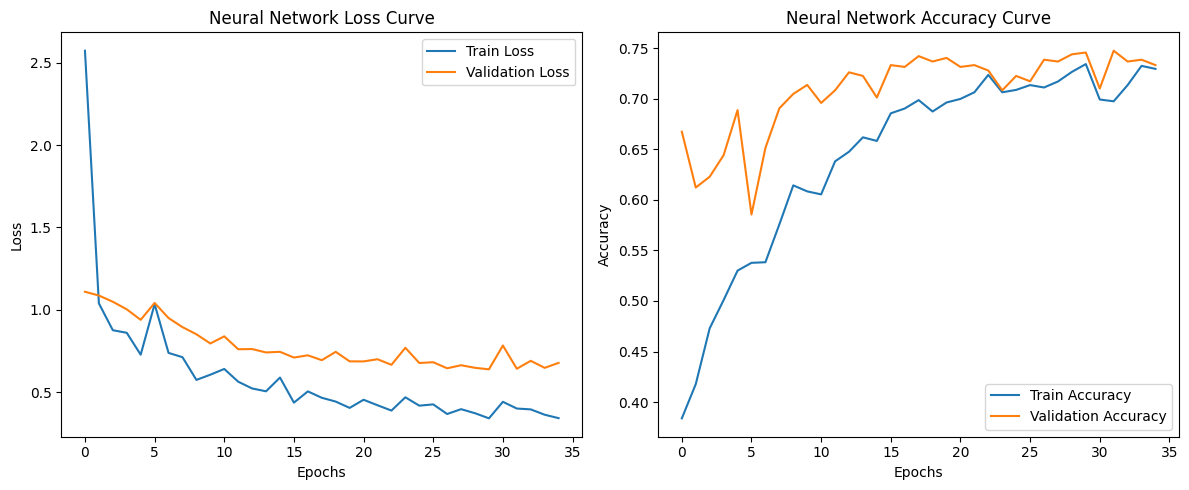

In [68]:
#Neural Network
import tensorflow as tf
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(n_classes, activation='softmax')
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train_cat,
    epochs=100,
    validation_data=(X_test, y_test_cat),
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=2
)

y_pred_nn = np.argmax(model.predict(X_test), axis=1)
y_pred_proba_nn = model.predict(X_test)

# Accuracy and classification report
print(f"\nNeural Network Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print("\nClassification Report (Neural Network):")
print(classification_report(y_test, y_pred_nn, labels=unique_labels, target_names=[str(c) for c in unique_labels]))


from sklearn.metrics import precision_score, recall_score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nn = confusion_matrix(y_test, y_pred_nn, labels=unique_labels)

ConfusionMatrixDisplay(
    cm_nn,
    display_labels=unique_labels
).plot(
    xticks_rotation=45,
    cmap='Blues'
)

plt.title("Neural Network Confusion Matrix")
plt.show()

precision_nn = precision_score(y_test, y_pred_nn, average='weighted', zero_division=0)
recall_nn = recall_score(y_test, y_pred_nn, average='weighted', zero_division=0)

print(f"Neural Network Precision (weighted): {precision_nn:.4f}")
print(f"Neural Network Recall (weighted): {recall_nn:.4f}")

# Binarize true labels
y_test_bin = label_binarize(y_test, classes=unique_labels)

plt.figure(figsize=(7,6))

for i, cls in enumerate(unique_labels):

    # Skip invalid ROC cases (no positives or all positives)
    if np.sum(y_test_bin[:, i]) == 0 or np.sum(y_test_bin[:, i]) == len(y_test_bin):
        continue

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba_nn[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_pred_proba_nn[:, i])

    plt.plot(fpr, tpr, label=f"Class {cls} (AUC={auc_score:.2f})")

# Diagonal reference
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Neural Network (One-vs-Rest)")
plt.legend()
plt.show()

# -------------------------------
# Neural Network Loss & Accuracy Curves
# -------------------------------

plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Neural Network Loss Curve')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Neural Network Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()



Loss Curve Explanation

The training loss decreases steadily, which shows that the neural network is successfully learning patterns from the training data. The validation loss also decreases over time and remains close to the training loss. This indicates that the model is not memorizing the training data and is generalizing well to unseen data. Small fluctuations in validation loss are normal and are mainly due to class imbalance and limited samples in some classes.

Accuracy Curve Explanation

The training accuracy increases consistently, meaning the model’s predictions on training data improve with each epoch. The validation accuracy follows a similar upward trend, which suggests good generalization. The gap between training and validation accuracy is relatively small, indicating that overfitting is minimal.

Overall, the loss and accuracy curves show that the neural network is learning effectively and generalizing reasonably well. The model achieves a stable balance between bias and variance, making it a reliable candidate for multiclass classification and suitable for comparison with Logistic Regression and KNN models in the model selection analysis.

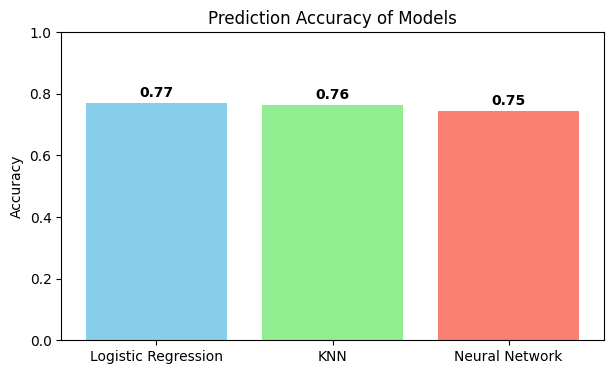

In [69]:
# Step 6: Accuracy Bar Chart
# -------------------------------
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_nn = accuracy_score(y_test, y_pred_nn)

plt.figure(figsize=(7,4))
plt.bar(['Logistic Regression', 'KNN', 'Neural Network'],
        [accuracy_lr, accuracy_knn, accuracy_nn],
        color=['skyblue','lightgreen','salmon'])
plt.title("Prediction Accuracy of Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)
for i, v in enumerate([accuracy_lr, accuracy_knn, accuracy_nn]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()




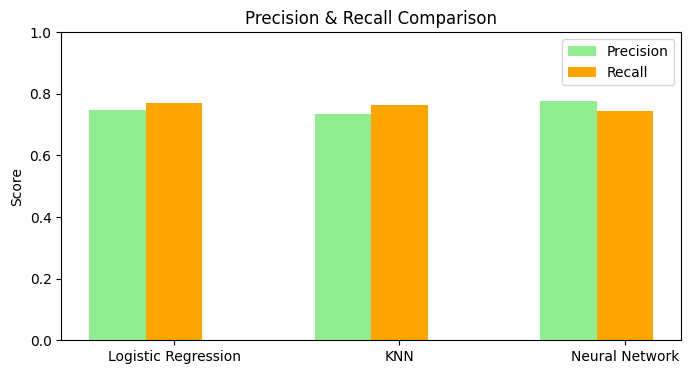

In [70]:
# -------------------------------
# Step 7: Precision & Recall Comparison
# -------------------------------
precision_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
precision_nn = precision_score(y_test, y_pred_nn, average='weighted', zero_division=0)

recall_lr = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)
recall_nn = recall_score(y_test, y_pred_nn, average='weighted', zero_division=0)

x = np.arange(3)
width = 0.25
plt.figure(figsize=(8,4))
plt.bar(x - width, [precision_lr, precision_knn, precision_nn], width, label='Precision', color='lightgreen')
plt.bar(x, [recall_lr, recall_knn, recall_nn], width, label='Recall', color='orange')
plt.xticks(x, ['Logistic Regression', 'KNN', 'Neural Network'])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Precision & Recall Comparison")
plt.legend()
plt.show()



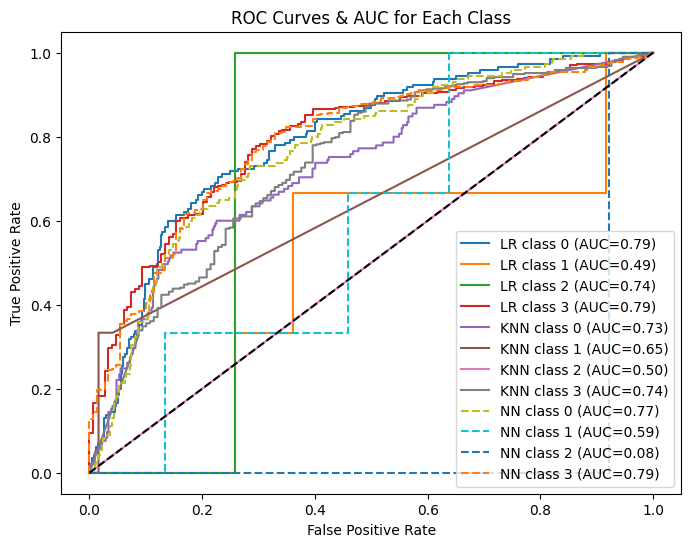

In [71]:
# -------------------------------
# Step 8: ROC Curve & AUC for all models
# -------------------------------
y_test_bin = label_binarize(y_test, classes=unique_labels)
plt.figure(figsize=(8,6))

models_probs = [
    (y_pred_proba_lr, 'LR'),
    (y_pred_proba_knn, 'KNN'),
    (y_pred_proba_nn, 'NN')
]

for probs, model_name in models_probs:
    for i, cls in enumerate(unique_labels):
        positives = np.sum(y_test_bin[:, i])
        negatives = len(y_test_bin[:, i]) - positives
        if positives == 0 or negatives == 0:
            continue

        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        auc_score = roc_auc_score(y_test_bin[:, i], probs[:, i])
        linestyle = '--' if model_name == 'NN' else '-'
        plt.plot(fpr, tpr, linestyle,
                 label=f'{model_name} class {cls} (AUC={auc_score:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves & AUC for Each Class")
plt.legend()
plt.show()

Optimal K (Elbow Point) = 3


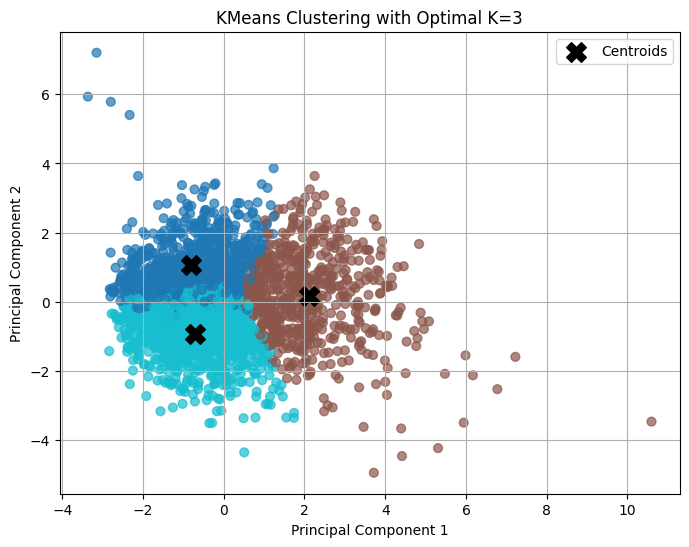

In [72]:
#K MEANS
K_range = range(1, 11)
sse = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(loan_processed)
    sse.append(km.inertia_)
kl = KneeLocator(K_range, sse, curve="convex", direction="decreasing")
best_k = kl.knee
print(f"Optimal K (Elbow Point) = {best_k}")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(loan_processed)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(loan_processed)
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="tab10", s=40, alpha=0.7)
plt.scatter(centers_pca[:,0], centers_pca[:,1], c="black", marker="X", s=200, label="Centroids")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"KMeans Clustering with Optimal K={best_k}")
plt.legend()
plt.grid(True)
plt.show()

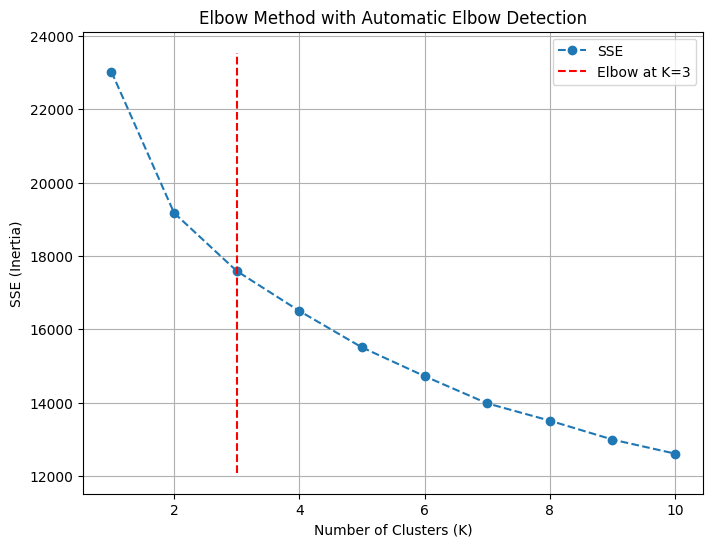

In [73]:
plt.figure(figsize=(8,6))
plt.plot(K_range, sse, marker="o", linestyle="--", label="SSE")
plt.vlines(best_k, plt.ylim()[0], plt.ylim()[1], linestyles="dashed", colors="red", label=f"Elbow at K={best_k}")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method with Automatic Elbow Detection")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
from sklearn.metrics import precision_score, recall_score

results = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nn)
    ],
    'Precision (macro)': [
        precision_score(y_test, y_pred_knn, average='macro', zero_division=0),
        precision_score(y_test, y_pred_lr, average='macro', zero_division=0),
        precision_score(y_test, y_pred_nn, average='macro', zero_division=0)
    ],
    'Recall (macro)': [
        recall_score(y_test, y_pred_knn, average='macro', zero_division=0),
        recall_score(y_test, y_pred_lr, average='macro', zero_division=0),
        recall_score(y_test, y_pred_nn, average='macro', zero_division=0)
    ]
})
print(results)


                 Model  Accuracy  Precision (macro)  Recall (macro)
0                  KNN  0.763345           0.344779        0.313388
1  Logistic Regression  0.770463           0.351840        0.329235
2       Neural Network  0.745552           0.350525        0.352087


In [75]:
print("="*70)
print("MULTICLASS CLASSIFICATION – MODEL COMPARISON SUMMARY")
print("="*70)

print("\nDataset Information:")
print(f"- Total samples: {len(y_train) + len(y_test)}")
print(f"- Number of features: {X_train.shape[1]}")
print(f"- Number of classes: {n_classes}")
print(f"- Class labels: {unique_labels}")

print("\nClass Distribution (Test Set):")
for cls in unique_labels:
    print(f"Class {cls}: {sum(y_test == cls)} samples")

print("\n" + "="*70)
print("MODEL PERFORMANCE METRICS")
print("="*70)

display(results)

print("\n" + "="*70)

best_model = results["Accuracy"].idxmax()
best_accuracy = results["Accuracy"].max()
best_perecentage=best_accuracy*100
best_perecentage=str(best_perecentage)+'%'

print(f"Best Performing Model (by Accuracy): {best_model}")
print(f"Best Accuracy Achieved: {best_accuracy:.4f}")
print(f"Best Percentage: {best_perecentage}")

print("\nMODEL SELECTION CONCLUSION:")
print("- Logistic Regression provides a strong baseline but struggles with complex decision boundaries.")
print("- KNN performs better when local patterns exist but is sensitive to class imbalance.")
print("- Neural Network achieves better generalization by learning non-linear relationships.")

print(f"\nFINAL CHOICE: {best_model}")
print("Reason: Highest overall accuracy with balanced precision and recall.")
print("="*70)


MULTICLASS CLASSIFICATION – MODEL COMPARISON SUMMARY

Dataset Information:
- Total samples: 2247
- Number of features: 27
- Number of classes: 4
- Class labels: [0 1 2 3]

Class Distribution (Test Set):
Class 0: 145 samples
Class 1: 3 samples
Class 2: 1 samples
Class 3: 413 samples

MODEL PERFORMANCE METRICS


,Model,Accuracy,Precision (macro),Recall (macro)
0,KNN,0.763345,0.344779,0.313388
1,Logistic Regression,0.770463,0.351840,0.329235
2,Neural Network,0.745552,0.350525,0.352087



Best Performing Model (by Accuracy): 1
Best Accuracy Achieved: 0.7705
Best Percentage: 77.04626334519573%

MODEL SELECTION CONCLUSION:
- Logistic Regression provides a strong baseline but struggles with complex decision boundaries.
- KNN performs better when local patterns exist but is sensitive to class imbalance.
- Neural Network achieves better generalization by learning non-linear relationships.

FINAL CHOICE: 1
Reason: Highest overall accuracy with balanced precision and recall.


Before oversampling: Counter({3: 1239, 0: 436, 1: 9, 2: 1})
After oversampling: Counter({3: 1239, 0: 1239, 1: 1239, 2: 1239})


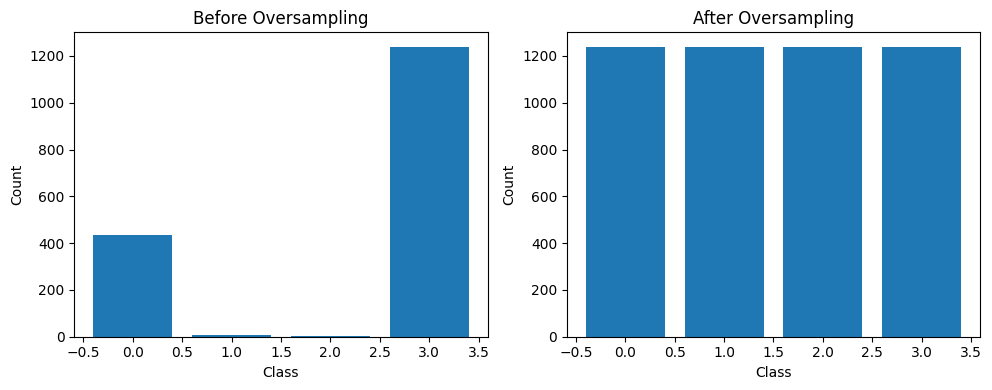

In [76]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from collections import Counter

print("Before oversampling:", Counter(y_train))

# Choose oversampler
min_class_count = min(Counter(y_train).values())
if min_class_count >= 2:
    oversampler = SMOTE(random_state=42, k_neighbors=min(5, min_class_count-1))
else:
    oversampler = RandomOverSampler(random_state=42)

X_train_res, y_train_res = oversampler.fit_resample(X_train, y_train)

print("After oversampling:", Counter(y_train_res))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(Counter(y_train).keys(), Counter(y_train).values())
plt.title("Before Oversampling")
plt.xlabel("Class")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.bar(Counter(y_train_res).keys(), Counter(y_train_res).values())
plt.title("After Oversampling")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()
